# **DLO-JZ Optimisation de l'apprentissage - Jour 2**
<img src="./images/optimisation.png" style="float: left; margin-right: 1em;"/>

<div class="alert alert-block alert-success">
    
## Objet des notebooks

Le but de ces trois *notebooks* est d'optimiser un code d'apprentissage d'un modèle *Resnet-50* sur *Imagenet* pour Jean Zay en implémentant :
* **TP2.1** : l'optimisation du *Dataloader*
* **TP2.2** : la distribution (*Data Parallelism*)
* **TP2.3** : le DDP et le problème des paramètres non utilisés


Les cellules dans ce *notebook* ne sont pas prévues pour être modifiées, sauf rares exceptions indiquées dans les commentaires. Les TP se feront en modifiant les codes `dlojz2_X.py`.

Les directives de modification seront marquées par l'étiquette suivante <div class="alert alert-block alert-warning">**TODO**</div>
Des solutions sont présentes dans le répertoire `solutions/`.

*Notebook rédigé par l'équipe assistance IA de l'IDRIS, mai 2026.*

</div>

### **Environnement de calcul**

Les fonctions *python* de gestion de queue SLURM développées par l'IDRIS et les fonctions dédiées à la formation DLO-JZ sont à importer.

Le module d'environnement pour les *jobs* et la taille des images sont fixés pour ce *notebook*.
<div class="alert alert-block alert-warning">
    
**TODO :** choisir un pseudonyme (maximum 5 caractères) pour vous différencier dans la queue SLURM pendant la formation.

</div>

In [1]:
from idr_pytools import display_slurm_queue, gpu_jobs_submitter, search_log
from dlojz_tools import controle_technique, compare, comm_profiler, turbo_profiler, BatchNorm_view, metric_compute_log
MODULE = 'pytorch-gpu/py3/2.8.0'
image_size = 224
account = 'sos@a100'
name = 'pseudo'   ## Pseudonyme à choisir
!mkdir -p checkpoints # Création d'un répertoire `checkpoints/` si cela n'a pas déjà été fait.

### **Gestion de la queue SLURM**

Pour afficher vos jobs dans la queue SLURM :

In [2]:
display_slurm_queue(name)


 Done!


**Remarque**: cette fonction sera utilisée plusieurs fois dans ce *notebook*. Elle permet d'afficher la queue de manière dynamique, rafraichie toutes les 5 secondes. Elle ne s'arrête que lorsque la queue est vide. Si vous désirez reprendre la main sur le *notebook*, il vous suffira d'arrêter manuellement la cellule avec le bouton *stop*. Cela n'a bien sûr aucun impact sur les *jobs* soumis.

Si vous voulez retirer TOUS vos *jobs* de la queue SLURM, décommenter et exécuter la cellule suivante :

In [3]:
#!scancel -u $USER

Si vous voulez retirer UN de vos *jobs* de la queue SLURM, décommenter, compléter et exécuter la cellule suivante :

In [4]:
#!scancel <jobid>

### Différence entre deux scripts

Pour comparer son code avec les solutions mises à disposition, la fonction suivante permet d'afficher une page HTML contenant un différentiel de fichiers texte.

In [5]:
s1 = "./dlojz2_2.py"
s2 = "./solutions/dlojz2_2.py"
compare(s1, s2)

Voir le résultat du différentiel de fichiers sur la page suivante (attention au spoil !) :

[compare.html](compare.html)

<div class="alert alert-block alert-success">
    
# TP2.1: Optimisation du DataLoader

Dans ce TP, on utilisera le script [dlojz2_1.py](./dlojz2_1.py) dans lequel le profiler PyTorch n'est pas implémenté. Ce script est identique à la solution du TP2_1.

Dans un premier temps, on va désactiver toutes les optimisations du DataLoader (**version sous-optimisée**). Ensuite,  nous pourrons observer l'impact de chacune des optimisations possibles en les réintégrant une par une.

## Découverte de turbo_profiler
Pour ce TP, nous avons implémenté un profiler maison léger `turbo_profiler` basé sur l'outil `Chronometer` pour visualiser le temps passé sur CPU (DataLoader) et sur GPU (le reste de l'itération). Ce profiler est moins précis mais cela nous permettra de désactiver le profiler PyTorch pour ne pas dégrader les performances et éviter de devoir ouvrir l'outil graphique TensorBoard à chaque fois pour visualiser les informations qui nous intéressent.

</div>

<div class="alert alert-block alert-info">

## Version sous-optimisée
<div class="alert alert-block alert-warning">
    
**TODO** : lancer l'exécution sur 1 GPU et 50 itérations (`--test-nsteps 50`) sans profiling pour passer un contrôle technique qui servira de référence. Cela va prendre quelques minutes (~5min), **vous pouvez passer à la suite sans attendre la fin de l'exécution**.

</div>
</div>

## Garage - Mise à niveau
On fixe la taille d'image pour ce TP et le batch size optimal d'après les expériences du Jour 1

In [6]:
image_size = 224
bs_optim = 512

### Soumission du job
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [7]:
n_gpu = 1
command = f'./dlojz2_1.py -b {bs_optim} --image-size {image_size} --test --test-nsteps 50'
command += f' --num-workers 0 --no-persistent-workers --no-pin-memory --no-non-blocking'
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name, account=account, time_max='00:10:00')
print(f'jobid = {jobid}')

batch job 0: 1 GPUs distributed on 1 nodes with 1 tasks / 1 gpus per node and 8 cpus per task
Submitted batch job 1606996
jobid = ['1606996']


Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [8]:
display_slurm_queue(name)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
           1606996    gpu_p5   pseudo  ssos043 CG       4:53      1 jean-zay-iam31

 Done!


<div class="alert alert-block alert-warning">

### **Quizz**

L'éxécution étant assez longue, un quizz vous attend : [Quizz TP2.1](https://www.deepmama.com/quizz/dlojz_quizz4.html)

</div>

In [9]:
controle_technique(jobid)

Train throughput: 134.86 images/second
GPU throughput: 1162.27 images/second
epoch time: 9502.52 seconds
-----------
training step time average (fwd/bkwd on GPU): 0.440519 sec (5.5%/94.9%) +/- 0.012979
loading step time average (IO + CPU to GPU transfer): 3.355932 sec +/- 0.530013


[Click here to display the log file](./slurm/log/pseudo@JZ_1606996_1nodes_1tasks_2026-06-01_15.59.51.out)

<div class="alert alert-block alert-warning">
    
**TODO** : visualiser la sortie de `turbo_profiler`

</div>

>>> Turbo Profiler >>> Training complete in 235.85881899999998 s


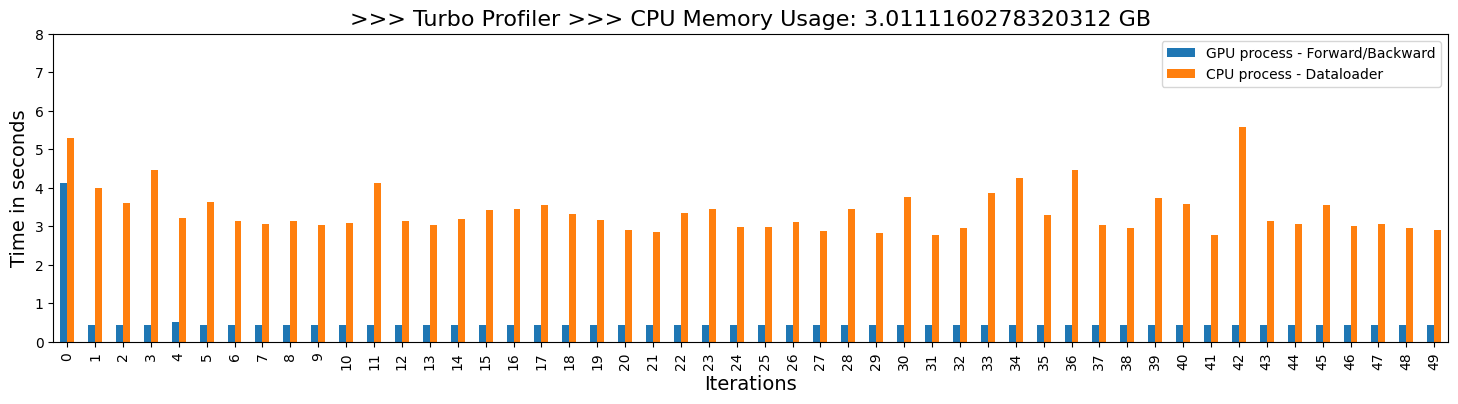

In [10]:
# call turbo_profiler
dataloader_trial = turbo_profiler(jobid,dataloader_info=True)

Via le turbo profiler, on va également récupérer et stocker les performances obtenues dans une DataFrame `dataloader_trials`
### Initialisation de la DataFrame :

In [11]:
import pandas as pd
dataloader_trials = pd.DataFrame({"jobid":pd.Series([],dtype=str),
                                  "num_workers":pd.Series([],dtype=int),
                                  "pin_memory":pd.Series([],dtype=str),
                                  "non_blocking":pd.Series([],dtype=str),
                                  "prefetch_factor":pd.Series([],dtype=int),
                                  "persistent_workers":pd.Series([],dtype=str),
                                  "drop_last":pd.Series([],dtype=str),
                                  "loading_time":pd.Series([],dtype=float),
                                  "1st_step_loading_time":pd.Series([],dtype=float),
                                  "CPU_memory_usage(GB)":pd.Series([],dtype=float)})

### Stockage du résultat précédent et visualisation de la *DataFrame* :

In [28]:
dataloader_trials = pd.concat([dataloader_trials,dataloader_trial])
dataloader_trials.sort_values("loading_time").drop_duplicates(keep="first", ignore_index=True) # trié par ordre croissant du LOADING_TIME

,jobid,num_workers,pin_memory,non_blocking,prefetch_factor,persistent_workers,drop_last,loading_time,1st_step_loading_time,CPU_memory_usage(GB)
0,1606996,0,False,False,2,False,False,3.355932,5.301708,3.011116


<div class="alert alert-block alert-info">

## Exploration des paramètres d'optimisation du DataLoader
L'objectif de ce TP est de réduire le temps passé sur CPU par le DataLoader.

Pour cette étude, on continue à lancer les exécutions sur 1 GPU et 50 itérations seulement (`--test-nsteps 50`) pour avancer plus rapidement. 

Les différentes optimisations proposées par le DataLoader de PyTorch sont accessibles dans le script `dlojz.py` via les arguments :
* `--num-workers <num_workers>` (défaut à `8`)
* `--persistent-workers` (défaut) ou `--no-persistent-workers`
* `--pin-memory` (défaut) ou `--no-pin-memory`
* `--non-blocking` (défaut) ou `--no-non-blocking`
* `--prefetch-factor <prefetch_factor>` (défaut à `2`, doit être >0)
* `--drop-last` ou `--no-drop-last` (défaut)

</div>

<div class="alert alert-block alert-warning">

**TODO** : répéter les étapes **1 à 4** suivantes en faisant varier ces différents paramètres et observer leurs effets grâce au profiler `turbo_profiler`. Pour comparer les différents essais, ceux-ci seront stockés dans la *DataFrame* `dataloader_trials` initialisée plus tôt.

</div>

#### 1. Soumission du job
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [35]:
command = f'./dlojz2_1.py -b {bs_optim} --image-size {image_size} --test --test-nsteps 50'

# paramètres d'entrée correspondant aux optimisations du DataLoader
command += ' --num-workers 8' 
command += ' --no-pin-memory'
command += ' --no-non-blocking'
command += ' --prefetch-factor 2'
command += ' --no-persistent-workers'
command += ' --no-drop-last'

n_gpu = 1
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00')
print(f'jobid = {jobid}')

batch job 0: 1 GPUs distributed on 1 nodes with 1 tasks / 1 gpus per node and 8 cpus per task
Submitted batch job 1607910
jobid = ['1607910']


In [36]:
display_slurm_queue(name)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
           1607910    gpu_p5   pseudo  ssos043  R       1:40      1 jean-zay-iam14

 Done!


#### 2. Visualiser le retour du turbo profiler :

>>> Turbo Profiler >>> Training complete in 47.099284 s


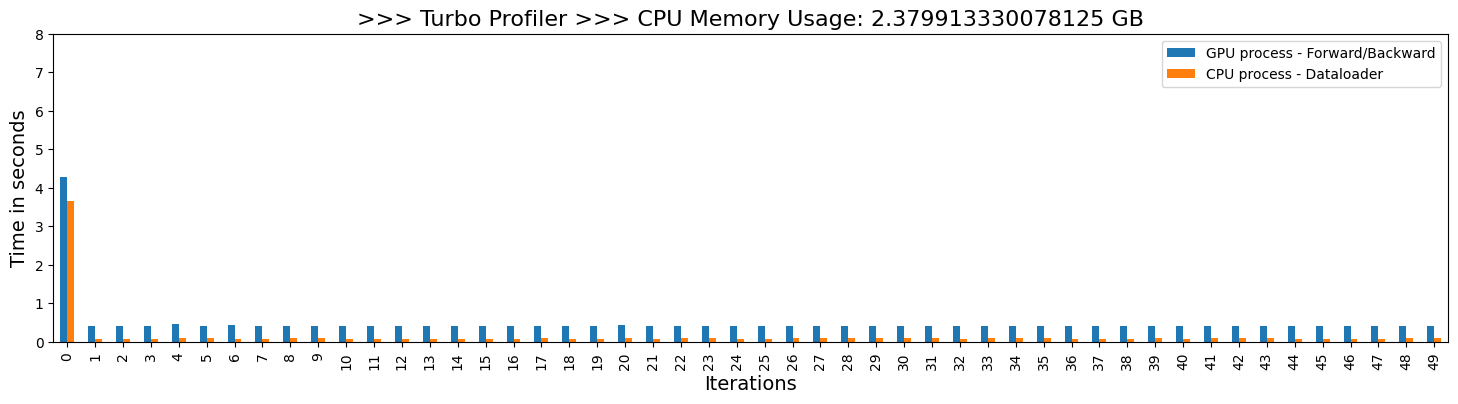

In [37]:
dataloader_trial = turbo_profiler(jobid, dataloader_info=True)

#### 3. Stocker le nouveau résultat et visualiser l'ensemble des runs :

In [38]:
dataloader_trials = pd.concat([dataloader_trials,dataloader_trial], ignore_index=True)
dataloader_trials.sort_values("loading_time").drop_duplicates(keep="first", ignore_index=True) # trié par ordre croissant du LOADING_TIME

,jobid,num_workers,pin_memory,non_blocking,prefetch_factor,persistent_workers,drop_last,loading_time,1st_step_loading_time,CPU_memory_usage(GB)
0,1607910,8,False,False,2,False,False,0.091364,3.654953,2.379913
1,1607834,2,False,False,2,False,False,1.080982,3.259814,2.384598
2,1606996,0,False,False,2,False,False,3.355932,5.301708,3.011116


<div class="alert alert-block alert-info">

## **Version optimisée** - Contrôle technique 

<div class="alert alert-block alert-warning">
    
**TODO** : relancer l'exécution sur 1 GPU et 100 itérations (`--test-nsteps 100`) sans profiling pour passer un nouveau contrôle technique, à comparer avec celui de référence.

</div>
</div>

### Soumission du job
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [19]:
command = f'./dlojz2_1.py -b {bs_optim} --image-size {image_size} --test --test-nsteps 100'

# définir ici les paramètres optimaux
command += ' --num-workers 0' 
command += ' --no-pin-memory'
command += ' --no-non-blocking'
command += ' --prefetch-factor 2'
command += ' --no-persistent-workers'
command += ' --no-drop-last'

n_gpu = 1
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00', qos="qos_gpu_a100-dev")
print(f'jobid = {jobid}')

batch job 0: 1 GPUs distributed on 1 nodes with 1 tasks / 1 gpus per node and 8 cpus per task
Submitted batch job 656699
jobid = ['656699']


Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [20]:
display_slurm_queue(name)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
            656699    gpu_p5      new  ssos043 CG       5:57      1 jean-zay-iam17

 Done!


>>> Turbo Profiler >>> Training complete in 324.56457 s


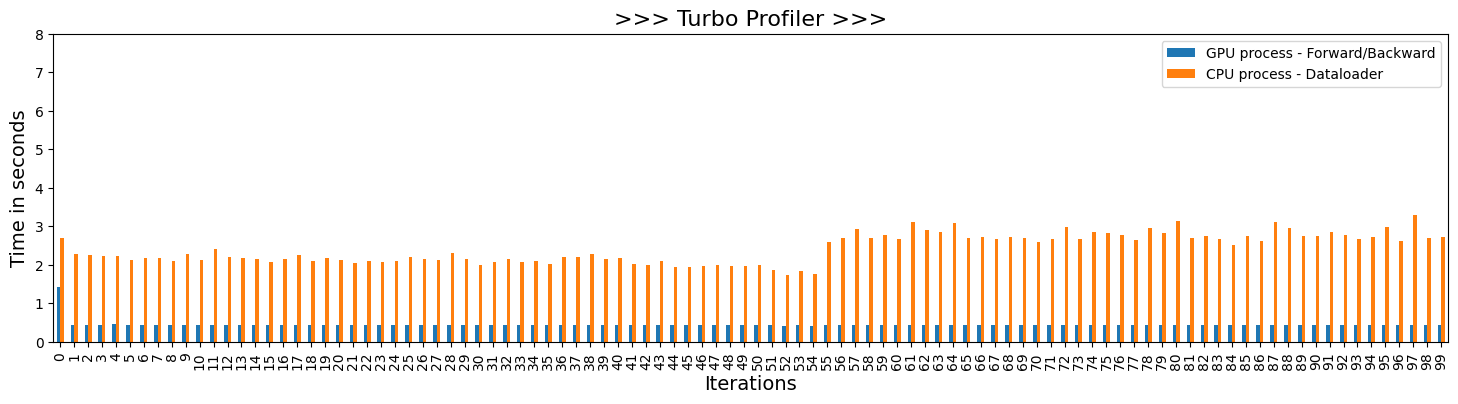

In [21]:
turbo_profiler(jobid)

In [22]:
controle_technique(jobid)

Train throughput: 178.80 images/second
GPU throughput: 1156.74 images/second
epoch time: 7167.51 seconds
-----------
training step time average (fwd/bkwd on GPU): 0.442624 sec (5.5%/94.4%) +/- 0.006093
loading step time average (IO + CPU to GPU transfer): 2.420945 sec +/- 0.373901


[Click here to display the log file](./slurm/log/new@JZ_656699_1nodes_1tasks_2026-05-07_15.05.51.out)

<div class="alert alert-block alert-info">

## **OPTIONNEL** : Visualisation des traces profiler avec TensorBoard (version sous optimisée)

<div class="alert alert-block alert-warning">

**TODO** : relancer le job en **réactivant le profiler PyTorch** dans le script [dlojz2_1.py](./dlojz2_1.py) (revoir le TP1_4) afin de visualiser les traces sous TensorBoard, et les comparer avec la version optimisée étudiée dans le TP1.4.

</div>
</div>

### Soumission du job
<u>**Attention vous sollicitez les noeuds de calcul à ce moment-là**.</u>

Pour soumettre le job, veuillez basculer la cellule suivante du mode `Raw NBConvert` au mode `Code` (raccourci: touche `Y` avec la cellule sélectionnée)

In [23]:
command = f'./dlojz2_1.py -b {bs_optim} --image-size {image_size} --test --test-nsteps 8'
command += f' --num-workers 0 --no-persistent-workers --no-pin-memory --no-non-blocking'

n_gpu = 1
jobid = gpu_jobs_submitter(command, n_gpu, MODULE, name=name,
                    account=account, time_max='00:10:00', qos="qos_gpu_a100-dev")
print(f'jobid = {jobid}')

batch job 0: 1 GPUs distributed on 1 nodes with 1 tasks / 1 gpus per node and 8 cpus per task
Submitted batch job 656813
jobid = ['656813']


Puis, rebasculer la cellule précédente en mode `Raw NBConvert`, afin d'eviter de relancer un job par erreur (raccourci: touche `R` avec la cellule sélectionnée).

In [24]:
display_slurm_queue(name)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
            656813    gpu_p5      new  ssos043  R       2:10      1 jean-zay-iam34

 Done!


<div class="alert alert-block alert-warning">

**TODO** : vérifier qu'une trace a bien été générée dans le répertoire `profiler/<name>_<jobid>_bs512_is224/` sous la forme d'un fichier `.json`:

</div>

In [25]:
!tree profiler/

profiler/ [error opening dir]

0 directories, 0 files


<div class="alert alert-block alert-warning">

**TODO** : visualiser cette trace grâce à l'application TensorBoard. 

</div>

<div class="alert alert-block alert-danger">

**IMPORTANT** : une fois le TP terminé, penser à quitter l'instance JupyterHub pour **libérer le GPU** ( *> Hub Control Panel > Cancel* ).

</div>

<img src="./images/stop.png" style="float: left; margin-right: 1em;"/>